# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> Data Science 2: Advanced Topics in Data Science

## Homework 2: Convolutional Neural Networks

**Harvard University**\
**Spring 2026**\
**Instructors**: Pavlos Protopapas & Kevin Rader

<hr style="height:2pt">


In [1]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as tvF

from tqdm.autonotebook import tqdm

# Reproducibility
SEED = 1090


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic runs are slower; enable if you need exact reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("device:", DEVICE)


/tmp/ipykernel_18190/1935564168.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
device: cuda


In [2]:
# Helper utilities (provided)
# These are small, readable helpers to keep dataset + DataLoader setup consistent.

# Prefer using a shared, pre-downloaded dataset directory on the course cluster when available.
# If you run this notebook elsewhere, it will fall back to a local ./data directory and download as needed.
SHARED_DATA_ROOT = Path("/shared/courseSharedFolders/163602outer/163602/datasets")
LOCAL_DATA_ROOT = Path("/mnt/ssd/Ubuntu-24.04/ssd-cs1090b/hw2/data")


def shared_or_local(
    check_path: Path,
    *,
    shared_dir: Path = SHARED_DATA_ROOT,
    local_dir: Path = LOCAL_DATA_ROOT,
):
    """Pick (root, download) for torchvision datasets.

    If `shared_dir/check_path` exists, we assume the dataset is already present and set download=False.
    Otherwise we use `local_dir` and set download=True only if `local_dir/check_path` is missing.
    """
    if (shared_dir / check_path).exists():
        return shared_dir, False
    return local_dir, not (local_dir / check_path).exists()


def subset_random(ds, n: int, seed: int):
    """Deterministically choose a random subset (without replacement)."""
    n = min(int(n), len(ds))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(ds), size=n, replace=False)
    return torch.utils.data.Subset(ds, idx)


def split_train_val(ds, val_size: int, seed: int):
    """Deterministic train/val split using torch.utils.data.random_split."""
    val_size = int(val_size)
    train_size = len(ds) - val_size
    if train_size <= 0:
        raise ValueError("val_size must be smaller than the dataset size.")
    g = torch.Generator().manual_seed(seed)
    return random_split(ds, [train_size, val_size], generator=g)


# Multiprocessing in Jupyter can be finicky (especially on macOS/Windows).
# Default to 0 workers for reliability. On Linux, you can bump this to 2–4 for speed.
NUM_WORKERS = 4


def make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size: int,
    *,
    device: torch.device,
    num_workers: int = NUM_WORKERS,
):
    """Standard train/val/test DataLoaders with sensible defaults."""
    pin = device.type == "cuda"
    common = dict(
        batch_size=int(batch_size),
        num_workers=int(num_workers),
        pin_memory=pin,
        persistent_workers=(num_workers > 0),
    )
    train_loader = DataLoader(train_ds, shuffle=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader


class RotateAngleRegressionDataset(Dataset):
    """Wrap a PIL-image dataset to produce (rotated_image_tensor, angle_deg).

    - `base_ds[idx]` may return an Image or (Image, target). We use only the image.
    - `angles_deg[i]` should be a 1D array-like of degrees (float).
    """

    def __init__(self, base_ds, angles_deg, *, preprocess=None, normalize=None, fill=0):
        self.base_ds = base_ds
        self.angles = np.asarray(angles_deg, dtype=np.float32)
        if len(self.angles) != len(self.base_ds):
            raise ValueError("angles_deg must have the same length as base_ds.")
        self.preprocess = preprocess  # PIL -> PIL (e.g., crop/resize)
        self.to_tensor = transforms.ToTensor()
        self.normalize = normalize  # Tensor -> Tensor (e.g., Normalize)
        self.fill = fill

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        img = item[0] if isinstance(item, (tuple, list)) else item  # PIL Image
        if self.preprocess is not None:
            img = self.preprocess(img)

        angle = float(self.angles[idx])
        img = tvF.rotate(
            img, angle, interpolation=tvF.InterpolationMode.BILINEAR, fill=self.fill
        )

        x = self.to_tensor(img)
        if self.normalize is not None:
            x = self.normalize(x)

        y = torch.tensor(angle, dtype=torch.float32)
        return x, y


In [ ]:
time_start = time.time()


<div style = "color: black; background: lightsalmon; border: thin solid black; border-radius: 2px; padding: 5px">

### Instructions

- To submit your notebook, follow the instructions given in on the Canvas assignment page.
- Plots should be legible and interpretable _without having to refer to the code that generated them_. They should includelabels for the $x$- and $y$-axes as well as a descriptive title and/or legend when appropriate.
- When asked to interpret a visualization, do not simply describe it (e.g., "the curve has a steep slope up"), but instead explain what you believe the plot _means_.
- Autograding tests are mostly to help you debug. The tests are not exhaustive so simply passing all tests may not be sufficient for full credit.
- The use of _extremely_ inefficient or error-prone code (e.g., copy-pasting nearly identical commands rather than looping) may result in only partial credit.
- We have tried to include all the libraries you may need to do the assignment in the imports cell provided below. Please get course staff approval before importing any additional 3rd party libraries.
- Enable scrolling output on cells with very long output.
- Feel free to add additional code or markdown cells as needed.
- Ensure your code runs top to bottom without error and passes all tests by restarting the kernel and running all cells (note that this can take a few minutes).
- **You should do a "Restart Kernel and Run All Cells" before submitting to ensure (1) your notebook actually runs and (2) all output is visible**
</div>


## About this Homework


In this homework, we will explore Convolutional Neural Networks (CNNs).

- In PART 1, we will begin by building a CNN to classify CIFAR-10 images. The low resolution of the dataset make it a smooth introduction to CNNs as we can get reasonable performance without huge models or long training times.

- Then, in PART 2, we will see that CNNs' impressive performance extends beyond just classifying images! They can serve as image input processing for a variety of tasks. This is demonstrated by training a network on the CelebA dataset to correct rotated images of faces to make them upright.

- Finally, in PART 3, we will look at a dataset of pet photos for image segmentation. This is a classification problem. But instead of assigning class probabilities to the image as a whole, we assign class probabilities for _each individual pixel_, identifying what regions of the image belong to each class (e.g., 'pet' or 'background').

**IMPORTANT NOTES:**

- Convolutional neural networks are computationally intensive.
- **We highly recommend that you train your model on a system using GPUs. For this, we recommend using [the GPU-enabled Jupyter environment provided to you as part of this course](https://ood.huit.harvard.edu/pun/sys/dashboard/batch_connect/sys/ood-jupyterlab-spack-mamba/cs1090b-gpu/session_contexts/new).**
- Models that take hours to train on CPUs can be trained in just minutes when using GPUs.
- **To avoid getting frustrated by having to re-train your models every time you run your notebook, you should save your trained model weights for later use.** Model histories can also be saved to disk with `pickle` and checked with an `if not` condition. This is a great way to check if the model weights exist before training, preventing redundant retraining. Please, think of the penguins! 🐧

**KERNEL CRASHES:**

If your kernel crashes as you attempt to train your model, please check the following items:

- Models with too many parameters might not fit in GPU memory. Try reducing the size of your model.
- A large batch size will attempt to load too many images in GPU memory. Avoid using a very large batch size.
- Avoid creating multiple copies of the data.


## PART 1: Building a Basic CNN Model

### Overview

In this question, you will use **PyTorch** to create a convolutional neural network for predicting the _type of object_ shown in each image from the [CIFAR-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html) dataset. CIFAR-10 contains 50,000 32×32 color training images and 10,000 test images, with 10 classes.


### 1.0 Loading & Preprocessing CIFAR-10

Here we load the CIFAR-10 dataset using `torchvision.datasets.CIFAR10`, converting the images tensors, make a train/val split, and create the train, val, and test DataLoaders for you. You may decide to modify parts of this code (e.g., the transforms) if you think it will improve model performance. Just be sure to justify any changes you make in a markdown cell.


In [ ]:
# CIFAR-10 dataset (cached on the course cluster)

train_tf = transforms.ToTensor()
test_tf = transforms.ToTensor()

CIFAR_CHECK = Path("cifar-10-batches-py/data_batch_1")
CIFAR_ROOT, cifar_download = shared_or_local(CIFAR_CHECK, local_dir=Path("data"))

train_full = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=True, download=cifar_download, transform=train_tf
)
test_ds = torchvision.datasets.CIFAR10(
    root=CIFAR_ROOT, train=False, download=cifar_download, transform=test_tf
)

# Create a true validation split from the training set
VAL_SIZE = 5000
train_ds, val_ds = split_train_val(train_full, val_size=VAL_SIZE, seed=SEED)

BATCH_SIZE = 128 if DEVICE.type == "cuda" else 64
train_loader, val_loader, test_loader = make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    num_workers=NUM_WORKERS,
)

print("CIFAR root:", CIFAR_ROOT, "| download:", cifar_download)
print("Split sizes:", len(train_ds), len(val_ds), len(test_ds))


### 1.1 Constructing the Model

Construct a classification model architecture using a combination of the following layers: Conv2d, MaxPool2d, Linear, Dropout and a flatten operation. The layers don’t necessarily need to be in this order, and you can use as many of these types of layers as you’d like.

- You may choose to construct your own implementation of a well-known architecture like AlexNet or VGG16, or you can create an architecture of your own devising.

- However, you MUST code the network yourself and not use a pre-written implementation.

- You must have multiple Conv2d layers.

- You are also permitted to use BatchNorm2d and different types of pooling layers _provided that you explain what they are doing and why they are helpful to your architecture_.


In [ ]:
# Your code here


### 1.2 Model parameter growth

How does the number of total parameters change (e.g. linearly, exponentially, etc.) as the number of filters per layer increases? You can find this empirically by constructing multiple models with the same type of architecture and increasing the number of filters. Generate a plot showing the relationship and explain why it has this relationship.

**HINT:** Completing this question is far easier if you write a function that generates your desired architecture in 1.1, with arguments that allow you to easily rebuild the architecture with varying numbers of filters per layer.


In [ ]:
# Your code here


**INTERPRETATION:**

_Your answer here_


### 1.3 Choose a model, train and evaluate it

#### 1.3.1

Use the `summary` function on your chosen architecture to display its structure and the total number of parameters. Then train your model using the CIFAR-10 DataLoaders that were created earlier. You can choose to train your model for as long as you'd like, but you should aim for at least 10 epochs. Report your validation and test accuracies. You can achieve a test accuracy of over 75% in about 6 minutes of training.

**Hint:** It would be helpful to add code which either saves your model to a local directory if it is the first time you're training it or loads your model if a saved file version currently exists in that directory. This will not only help save time when you rerun your notebook, but it will also ensure reproducible results in the rest of Part 1.


In [ ]:
def summarize(model: nn.Module, input_shape=(3, 32, 32)):
    """Print a minimal parameter + shape summary."""
    print(model)
    print(f"trainable params: {count_parameters(model):,}")
    dummy = torch.zeros(1, *input_shape)
    with torch.no_grad():
        out = model(dummy)
    print("output shape:", tuple(out.shape))


In [ ]:
# Specify model and display summary
# Your code here


In [ ]:
# Train cifar-10 model
# Your code here


In [ ]:
# Evaluate trained model on the train, validation, and test set,
# reporting loss and accuracy for each.
# Your code here


#### 1.3.2

Plot the training loss and accuracy per epoch (both train and validation) for your chosen architecture.


In [ ]:
# Trace Plot of training history
# Your code here


## PART 2: Regression with CNN

### Overview

**In this problem we will construct a neural network to predict how far a face is from being "upright"**.

**Image orientation estimation**

Image orientation estimation with convolutional networks was first implemented in 2015 by Fischer, Dosovitskiy, and Brox in a paper titled ["Image Orientation Estimation with Convolutional Networks"](https://lmb.informatik.uni-freiburg.de/Publications/2015/FDB15/image_orientation.pdf). In that paper, the authors trained a network to straighten a wide variety of images using the [Microsoft COCO dataset](https://cocodataset.org/#home).

**The modified CelebA dataset**

In order to have a reasonable training time for a homework, we will be working on a subset of the problem where we just straighten images of faces. To do this:

- We will be using the [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) dataset of celebrity faces, where we assume that professional photographers have taken level pictures;

- The training will be supervised, with a rotated image (up to $\pm 60^\circ$) as an input, and the amount (in degrees) that the image has been rotated as a target.


### 2.1 Data preparation

#### 2.1.0

**Loading the CelebA Dataset.** Run the cells provided to load a subset of the CelebA faces dataset and build PyTorch `Dataset`/`DataLoader`s.

In Part 2 we’ll generate _randomly rotated_ face images and train a CNN to regress the rotation angle (in degrees). To follow good ML practice, we will use **three** splits:

- **train**: used to fit model parameters
- **validation**: used for early stopping / model selection
- **test**: held out until the end for a final, unbiased evaluation

To make runs reproducible, keep the random seed fixed and make any subsampling/splitting deterministic.


In [ ]:
# CelebA rotation-regression dataset (provided)

CELEBA_CHECK = Path("celeba/img_align_celeba/000001.jpg")
CELEBA_ROOT, celeba_download = shared_or_local(CELEBA_CHECK)

# 1) Load official splits
celeba_train = torchvision.datasets.CelebA(
    root=CELEBA_ROOT, split="train", target_type=[], download=celeba_download
)
celeba_val = torchvision.datasets.CelebA(
    root=CELEBA_ROOT, split="valid", target_type=[], download=celeba_download
)
celeba_test = torchvision.datasets.CelebA(
    root=CELEBA_ROOT, split="test", target_type=[], download=celeba_download
)

# 2) Subsample for a faster notebook run (tweak up/down)
N_TRAIN, N_VAL, N_TEST = 8000, 2000, 2000
celeba_train = subset_random(celeba_train, N_TRAIN, seed=SEED)
celeba_val = subset_random(celeba_val, N_VAL, seed=SEED + 1)
celeba_test = subset_random(celeba_test, N_TEST, seed=SEED + 2)

# 3) Preprocess + normalize
preprocess = transforms.Compose(
    [transforms.CenterCrop(160), transforms.Resize((140, 120))]
)
normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # map to [-1, 1]

# 4) Deterministic angles in [-60, 60] and wrap into regression datasets
angles_train = np.random.RandomState(SEED).uniform(-60, 60, size=len(celeba_train))
angles_val = np.random.RandomState(SEED + 1).uniform(-60, 60, size=len(celeba_val))
angles_test = np.random.RandomState(SEED + 2).uniform(-60, 60, size=len(celeba_test))

train_rot_ds = RotateAngleRegressionDataset(
    celeba_train, angles_train, preprocess=preprocess, normalize=normalize
)
val_rot_ds = RotateAngleRegressionDataset(
    celeba_val, angles_val, preprocess=preprocess, normalize=normalize
)
test_rot_ds = RotateAngleRegressionDataset(
    celeba_test, angles_test, preprocess=preprocess, normalize=normalize
)

# 5) Train/val/test loaders
BATCH_SIZE_ROT = 256 if DEVICE.type == "cuda" else 64
train_rot_loader, val_rot_loader, test_rot_loader = make_loaders(
    train_rot_ds,
    val_rot_ds,
    test_rot_ds,
    batch_size=BATCH_SIZE_ROT,
    device=DEVICE,
    num_workers=NUM_WORKERS,
)

x0, y0 = next(iter(train_rot_loader))
print("CelebA root:", CELEBA_ROOT, "| download:", celeba_download)
print(
    "train_rot batch:",
    x0.shape,
    x0.dtype,
    "| angle:",
    y0.shape,
    y0.dtype,
    "| min/max:",
    y0.min().item(),
    y0.max().item(),
)


#### 2.1.1

**Taking a look.** In a grid of subplots, plot at least 6 rotated images from your training loader/dataset with the titles being the amount the images have been rotated. The floating point numbers in the titles should have a reasonable number of digits.


In [3]:
# Helper functions
def denorm_01(x: torch.Tensor) -> torch.Tensor:
    """Inverse of Normalize((0.5,),(0.5,)) for visualization; expects (C,H,W)."""
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_tensor_image(x: torch.Tensor, title: str | None = None):
    x = denorm_01(x.detach().cpu())
    x = x.permute(1, 2, 0).numpy()
    plt.imshow(x)
    plt.axis("off")
    if title is not None:
        plt.title(title)


In [ ]:
# Plot some celebA images, rotated
# Your code here


### 2.2 Building and training your CNN

#### 2.2.1 Defining your model

Construct a CNN regressor with multiple convolutional layers (and any other layers you think will help). Display a summary of the model and report the total number of parameters. You do **not** need more than a few million parameters.

**Note:** It is fine to implement a well-known architecture idea (e.g., VGG-style blocks), but you may not import a pre-built model. Build the network layer-by-layer in your own code.


In [ ]:
# For context, its a good idea to view the shape of our rotated image batches
xb, yb = next(iter(train_rot_loader))
print("X batch:", xb.shape, "y batch:", yb.shape)


In [ ]:
# Construct Model
# Your code here


#### 2.2.2 Training and saving your model

Train your rotation-regression model using your rotated CelebA training set and report the loss and MAE (mean absolute error) on the train, validation, and test sets.

You _must_ save your best model weights to disk so rerunning the notebook does **not** require retraining but instead loads your trained model from disk.

You may use any reasonable optimizer/scheduler. Report your final train and validation losses.


In [ ]:
# Train and save your model
# Your code here



In [ ]:
# Evaluate trained model (train / val / test)
# Your code here



#### 2.2.3 Visual inspection of predictions

Create a subplots grid with **4 rows × 3 columns**. Each row is a separate image from the _test_ set, and each column is:

1. Original (rotated) image
2. Predicted straightened image (rotate by **− predicted angle**)
3. Target straightened image (rotate by **− true angle**)

Title columns (2) and (3) with the predicted rotation and actual rotation, respectively. Your regressor expects a batch dimension, so be careful about tensor shapes.


In [ ]:
# Rotation helpers for visualization (may be useful)
def _unwrap_subset(ds):
    # Handle Subset(Subset(...)) etc.
    while hasattr(ds, "dataset"):
        ds = ds.dataset
    return ds


def rotate_tensor_vis(x, angle_deg, *, norm=None):
    """
    Rotate a single image tensor for visualization.
    - If `norm` is provided (transforms.Normalize), we unnormalize -> rotate -> renormalize.
    - Returns a CPU tensor (good for matplotlib).
    """
    to_pil = transforms.ToPILImage()
    to_tensor = transforms.ToTensor()

    x = x.detach().cpu()

    # If the tensor is normalized, undo it back to [0,1] before converting to PIL
    if norm is not None:
        mean = torch.tensor(norm.mean).view(-1, 1, 1)
        std = torch.tensor(norm.std).view(-1, 1, 1)
        x01 = x * std + mean
    else:
        x01 = x

    x01 = x01.clamp(0, 1)
    pil = to_pil(x01)
    pil_rot = tvF.rotate(
        pil, float(angle_deg), interpolation=tvF.InterpolationMode.BILINEAR, fill=0
    )

    x_rot = to_tensor(pil_rot)

    if norm is not None:
        x_rot = norm(x_rot)

    return x_rot


In [ ]:
# Visual prediciton insepction
# Your code here


## PART 3: Image Segmentation

### Overview

In this section, we will use the Oxford-IIIT Pet dataset to design a model for an image segmentation task.

[Semantic image segmentation](https://arxiv.org/abs/2302.06378) is a computer vision application where we assign a semantically meaningful label, or class, to every pixel in the image. For example, a camera on a self-driving car would segment the imagery around it into semantic labels such as "Road", "Person", "Bike", etc.

Our dataset contains images of various pet breeds along with their corresponding segmentation masks. Each raw image is 500x403 with three RGB channels, while the corresponding mask is of the same size but contains only a single channel, indicating the pixel class.

For simplicity, we resize both the images and masks to 64x64 to speed up training.
We have also provided all the necessary preprocessing code for you as well as some functions for visualization.


In [4]:
# Oxford-IIIT Pet segmentation dataset (images + trimap masks)

PET_CHECK = Path("oxford-iiit-pet/images")
PET_ROOT, download_pets = shared_or_local(PET_CHECK)
print("Pets root:", PET_ROOT, "| download:", download_pets)

pets_trainval = torchvision.datasets.OxfordIIITPet(
    root=PET_ROOT, split="trainval", target_types="segmentation", download=download_pets
)
pets_test = torchvision.datasets.OxfordIIITPet(
    root=PET_ROOT, split="test", target_types="segmentation", download=download_pets
)

print("trainval:", len(pets_trainval), "| test:", len(pets_test))


Pets root: /mnt/ssd/Ubuntu-24.04/ssd-cs1090b/hw2/data | download: False
trainval: 3680 | test: 3669


In [5]:
# Preprocessing utilities for images + masks
IMG_SIZE = (64, 64)  # (H, W)

img_tf_pet = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, antialias=True),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)


def preprocess_mask(mask_pil, mode: str):
    """Convert the Oxford-IIIT Pet trimap mask into a training target.

    The provided masks are "trimaps" with values {1,2,3}:
      - 1: pet
      - 2: background
      - 3: border/outline (ambiguous)

    Modes:
      - "binary": return {0,1} where 1 = pet, 0 = background (treat border as background)
      - "three_class": return {0,1,2} where 0 = background, 1 = pet, 2 = border
    """
    mode = mode.lower()
    if mode in {"3class", "3-class", "threeclass"}:
        mode = "three_class"

    m = transforms.Resize(IMG_SIZE, antialias=False)(mask_pil)  # keep labels sharp
    m = np.array(m, dtype=np.int64)

    if mode == "binary":
        # pet(1) -> 1.0, everything else -> 0.0
        y = (m == 1).astype(np.float32)
        return torch.from_numpy(y)
    elif mode == "three_class":
        # map {2(background),1(pet),3(border)} -> {0,1,2}
        y = np.zeros_like(m, dtype=np.int64)
        y[m == 1] = 1
        y[m == 3] = 2
        return torch.from_numpy(y)
    else:
        raise ValueError("mode must be 'binary' or 'three_class'")


class PetSegDataset(Dataset):
    """Wrap Oxford-IIIT Pet, returning (image_tensor, mask_tensor)."""

    def __init__(self, base_ds, mode: str = "binary"):
        self.ds = base_ds
        self.mode = mode

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]  # PIL image + PIL mask
        x = img_tf_pet(img)
        y = preprocess_mask(mask, self.mode)
        return x, y


In [6]:
# Helper code to prepare datasets + loaders for binary segmentation (train/val/test)

pet_full_bin = PetSegDataset(pets_trainval, mode="binary")
pet_test_bin = PetSegDataset(pets_test, mode="binary")

VAL_SIZE = 800
pet_train_bin, pet_val_bin = split_train_val(pet_full_bin, val_size=VAL_SIZE, seed=SEED)

BATCH_PET = 128 if DEVICE.type == "cuda" else 32
train_pet_loader, val_pet_loader, test_pet_loader = make_loaders(
    pet_train_bin,
    pet_val_bin,
    pet_test_bin,
    BATCH_PET,
    device=DEVICE,
    num_workers=NUM_WORKERS,
)

xb, yb = next(iter(train_pet_loader))
print("pet batch:", xb.shape, yb.shape, "| mask unique:", torch.unique(yb))


/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.

pet batch: torch.Size([128, 3, 64, 64]) torch.Size([128, 64, 64]) | mask unique: tensor([0., 1.])


#### EDA


In [7]:
pet_full_bin[0][0].shape


torch.Size([3, 64, 64])

In [8]:
pets_trainval.classes.__len__()


37

### 3.1 Deep CNN for Image Segmentation

Here you'll design a PyTorch segmentation model (train on **train**, tune on **validation**, and report final performance on **test**) that utilizes convolutional layers and **skip connections**. The model should perform **binary** pixel-wise classification using the provided Oxford-IIIT Pet segmentation masks. Store the trained model in a variable called `model_deepcnn`.

Minimum Requirements:

- A reasonably deep CNN architecture (you should be able to reach >80% validation pixel accuracy with ~90 seconds of training on a GPU).
- Accepts an input size of **64 × 64 × 3** and outputs a **64 × 64** binary mask prediction.
- At least **four skip connections** placed appropriately.
- Uses an appropriate loss function and record its value and average pixel accuracy at each epoch.
- Saves trained model and training history to disk to avoid retraining when notebook is re-run
- Reports final model's loss and accuracy on train, validation, and test.
- Plots loss and accuracy for train and validation data across training epochs.


Here are some of the images and their corresponding segmentation masks. The segmentation mask categorizes each pixel into two classes: "background" or "pet".


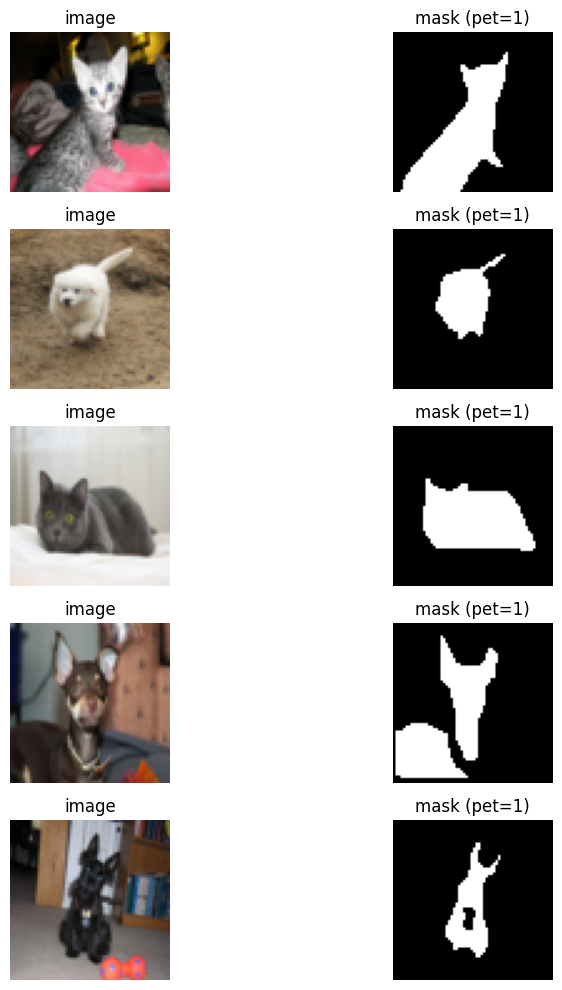

In [9]:
# Helper code to visualize a few training examples (binary masks)
xb, yb = next(iter(train_pet_loader))
n = 5
plt.figure(figsize=(10, 2 * n))
for i in range(n):
    img = denorm_01(xb[i].cpu()).permute(1, 2, 0).numpy()
    msk = yb[i].cpu().numpy()

    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("image")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(msk, cmap="gray")
    plt.axis("off")
    plt.title("mask (pet=1)")
plt.tight_layout()
plt.show()


In [7]:
class CableNewsNetwork_NowOwnedByParamount(nn.Module):
    def __init__(self):
        super(CableNewsNetwork_NowOwnedByParamount, self).__init__()
        self.input_shape = (3, 64, 64)  # pet_full_bin[0][0].shape
        self.max_filters = 256

        # downwards architecture
        # dstep 1: 64x64 -> 64x64
        self.dconv1 = nn.Conv2d(3, self.max_filters >> 4, kernel_size=3, padding=1)
        self.dbn1 = nn.BatchNorm2d(self.max_filters >> 4)
        self.drelu1 = nn.ReLU()
        self.dconv2 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.dbn2 = nn.BatchNorm2d(self.max_filters >> 4)
        self.drelu2 = nn.ReLU()

        # dstep 2: 64x64 -> 32x32
        self.dpool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv4 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.dbn4 = nn.BatchNorm2d(self.max_filters >> 3)
        self.drelu4 = nn.ReLU()
        self.dconv5 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.dbn5 = nn.BatchNorm2d(self.max_filters >> 3)
        self.drelu5 = nn.ReLU()

        # dstep 3: 32x32 -> 16x16
        self.dpool6 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv7 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.dbn7 = nn.BatchNorm2d(self.max_filters >> 2)
        self.drelu7 = nn.ReLU()
        self.dconv8 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.dbn8 = nn.BatchNorm2d(self.max_filters >> 2)
        self.drelu8 = nn.ReLU()

        # dstep 4: 16x16 -> 8x8
        self.dpool9 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv10 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.dbn10 = nn.BatchNorm2d(self.max_filters >> 1)
        self.drelu10 = nn.ReLU()
        self.dconv11 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.dbn11 = nn.BatchNorm2d(self.max_filters >> 1)
        self.drelu11 = nn.ReLU()

        # dstep 5: 8x8 -> 4x4
        self.dpool12 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv13 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters, kernel_size=3, padding=1
        )
        self.dbn13 = nn.BatchNorm2d(self.max_filters)
        self.drelu13 = nn.ReLU()
        self.dconv14 = nn.Conv2d(
            self.max_filters, self.max_filters, kernel_size=3, padding=1
        )
        self.dbn14 = nn.BatchNorm2d(self.max_filters)
        self.drelu14 = nn.ReLU()

        # upsample architecture
        # step 1: 4x4 -> 8x8
        self.uupsample1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv1 = nn.Conv2d(
            self.max_filters, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn1 = nn.BatchNorm2d(self.max_filters >> 1)
        self.uconv2 = nn.Conv2d(
            self.max_filters, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn2 = nn.BatchNorm2d(self.max_filters >> 1)
        self.urelu2 = nn.ReLU()
        self.uconv3 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn3 = nn.BatchNorm2d(self.max_filters >> 1)
        self.urelu3 = nn.ReLU()

        # step 2: 8x8 -> 16x16
        self.uupsample4 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv4 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn4 = nn.BatchNorm2d(self.max_filters >> 2)
        self.uconv5 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn5 = nn.BatchNorm2d(self.max_filters >> 2)
        self.urelu5 = nn.ReLU()
        self.uconv6 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn6 = nn.BatchNorm2d(self.max_filters >> 2)
        self.urelu6 = nn.ReLU()

        # step 3: 16x16 -> 32x32
        self.uupsample7 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv7 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn7 = nn.BatchNorm2d(self.max_filters >> 3)
        self.uconv8 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn8 = nn.BatchNorm2d(self.max_filters >> 3)
        self.urelu8 = nn.ReLU()
        self.uconv9 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn9 = nn.BatchNorm2d(self.max_filters >> 3)
        self.urelu9 = nn.ReLU()

        # step 4: 32x32 -> 64x64
        self.uupsample10 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv10 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn10 = nn.BatchNorm2d(self.max_filters >> 4)
        self.uconv11 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn11 = nn.BatchNorm2d(self.max_filters >> 4)
        self.urelu11 = nn.ReLU()
        self.uconv12 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn12 = nn.BatchNorm2d(self.max_filters >> 4)
        self.urelu12 = nn.ReLU()

        # final conv to get 1 output channel for binary segmentation
        self.final_conv = nn.Conv2d(self.max_filters >> 4, 1, kernel_size=1)

    def forward(self, x):
        # downsample
        x = self.drelu1(self.dbn1(self.dconv1(x)))
        x = self.drelu2(self.dbn2(self.dconv2(x)))
        skip1 = x.clone()  # 64x64

        x = self.dpool3(x)
        x = self.drelu4(self.dbn4(self.dconv4(x)))
        x = self.drelu5(self.dbn5(self.dconv5(x)))
        skip2 = x.clone()  # 32x32

        x = self.dpool6(x)
        x = self.drelu7(self.dbn7(self.dconv7(x)))
        x = self.drelu8(self.dbn8(self.dconv8(x)))
        skip3 = x.clone()  # 16x16

        x = self.dpool9(x)
        x = self.drelu10(self.dbn10(self.dconv10(x)))
        x = self.drelu11(self.dbn11(self.dconv11(x)))
        skip4 = x.clone()  # 8x8

        x = self.dpool12(x)
        x = self.drelu13(self.dbn13(self.dconv13(x)))
        x = self.drelu14(self.dbn14(self.dconv14(x)))  # 4x4

        # upsample
        x = self.ubn1(self.uconv1(self.uupsample1(x)))
        x = self.urelu2(self.ubn2(self.uconv2(torch.cat([x, skip4], dim=1))))
        x = self.urelu3(self.ubn3(self.uconv3(x)))  # 8x8

        x = self.ubn4(self.uconv4(self.uupsample4(x)))
        x = self.urelu5(self.ubn5(self.uconv5(torch.cat([x, skip3], dim=1))))
        x = self.urelu6(self.ubn6(self.uconv6(x)))  # 16x16

        x = self.ubn7(self.uconv7(self.uupsample7(x)))
        x = self.urelu8(self.ubn8(self.uconv8(torch.cat([x, skip2], dim=1))))
        x = self.urelu9(self.ubn9(self.uconv9(x)))  # 32x32

        x = self.ubn10(self.uconv10(self.uupsample10(x)))
        x = self.urelu11(self.ubn11(self.uconv11(torch.cat([x, skip1], dim=1))))
        x = self.urelu12(self.ubn12(self.uconv12(x)))  # 64x64

        x = self.final_conv(x)  # 64x64, 1 channel
        return x.squeeze(1)  # (B, 1, H, W) -> (B, H, W)


# model object
model_deepcnn = CableNewsNetwork_NowOwnedByParamount()


In [31]:
CHECKPOINT_PATH = Path("/mnt/ssd/Ubuntu-24.04/ssd-cs1090b/hw2/deepcnn/")
CHECKPOINT_PATH.mkdir(exist_ok=True, parents=True)


def train_pet_seg_model(
    model, train_loader, val_loader, test_loader, device, num_epochs=10
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        for xb, yb in tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Train", leave=False
        ):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) > 0.5).long()
            correct_train += (preds == yb).sum().item()
            total_train += yb.numel()

        train_loss /= len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for xb, yb in tqdm(
                val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Val", leave=False
            ):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb.float())
                val_loss += loss.item() * xb.size(0)

                preds = (torch.sigmoid(logits) > 0.5).long()
                correct_val += (preds == yb).sum().item()
                total_val += yb.numel()

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Test
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for xb, yb in tqdm(
                test_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Test", leave=False
            ):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb.float())
                test_loss += loss.item() * xb.size(0)

                preds = (torch.sigmoid(logits) > 0.5).long()
                correct_test += (preds == yb).sum().item()
                total_test += yb.numel()

        test_loss /= len(test_loader.dataset)
        test_acc = correct_test / total_test
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

        # Save model checkpoint
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "performance": {
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
            },
        }
        torch.save(checkpoint, CHECKPOINT_PATH / f"checkpoint_epoch_{epoch}.pt")

    return history


In [33]:
# Build, train, and evaluate final binary segmentation model
METRICS_PATH = CHECKPOINT_PATH / "metrics_deepcnn.pt"

deepcnn_num_epochs = 10
pet_seg_train_results = None

if (CHECKPOINT_PATH / f"checkpoint_epoch_{deepcnn_num_epochs - 1}.pt").exists():
    print("already trained, skipping training...")
    pet_seg_train_results = torch.load(METRICS_PATH)
else:
    pet_seg_train_results = train_pet_seg_model(
        model_deepcnn,
        train_pet_loader,
        val_pet_loader,
        test_pet_loader,
        DEVICE,
        num_epochs=10,
    )
    torch.save(pet_seg_train_results, METRICS_PATH)

# load best checkpoint
best_epoch = np.argmax(pet_seg_train_results["val_acc"])
best_checkpoint = torch.load(CHECKPOINT_PATH / f"checkpoint_epoch_{best_epoch}.pt")
model_deepcnn.load_state_dict(best_checkpoint["model_state_dict"])


Epoch 1/10 | Train Loss: 0.3653, Train Acc: 0.8407 | Val Loss: 0.3143, Val Acc: 0.8772 | Test Loss: 0.3539, Test Acc: 0.8635


Epoch 2/10 | Train Loss: 0.2345, Train Acc: 0.9035 | Val Loss: 0.2457, Val Acc: 0.9025 | Test Loss: 0.2785, Test Acc: 0.8900


Epoch 3/10 | Train Loss: 0.2076, Train Acc: 0.9141 | Val Loss: 0.2359, Val Acc: 0.9052 | Test Loss: 0.2716, Test Acc: 0.8912


Epoch 4/10 | Train Loss: 0.1914, Train Acc: 0.9209 | Val Loss: 0.2316, Val Acc: 0.9076 | Test Loss: 0.2717, Test Acc: 0.8923


Epoch 5/10 | Train Loss: 0.1791, Train Acc: 0.9265 | Val Loss: 0.2293, Val Acc: 0.9070 | Test Loss: 0.2692, Test Acc: 0.8921


...

Epoch 7/10 | Train Loss: 0.1581, Train Acc: 0.9353 | Val Loss: 0.2319, Val Acc: 0.9054 | Test Loss: 0.2633, Test Acc: 0.8936


Epoch 8/10 | Train Loss: 0.1534, Train Acc: 0.9371 | Val Loss: 0.2204, Val Acc: 0.9113 | Test Loss: 0.2502, Test Acc: 0.9004


Epoch 9/10 | Train Loss: 0.1457, Train Acc: 0.9404 | Val Loss: 0.2145, Val Acc: 0.9156 | Test Loss: 0.2493, Test Acc: 0.9027


Epoch 10/10 | Train Loss: 0.1384, Train Acc: 0.9434 | Val Loss: 0.2140, Val Acc: 0.9152 | Test Loss: 0.2485, Test Acc: 0.9026


<All keys matched successfully>

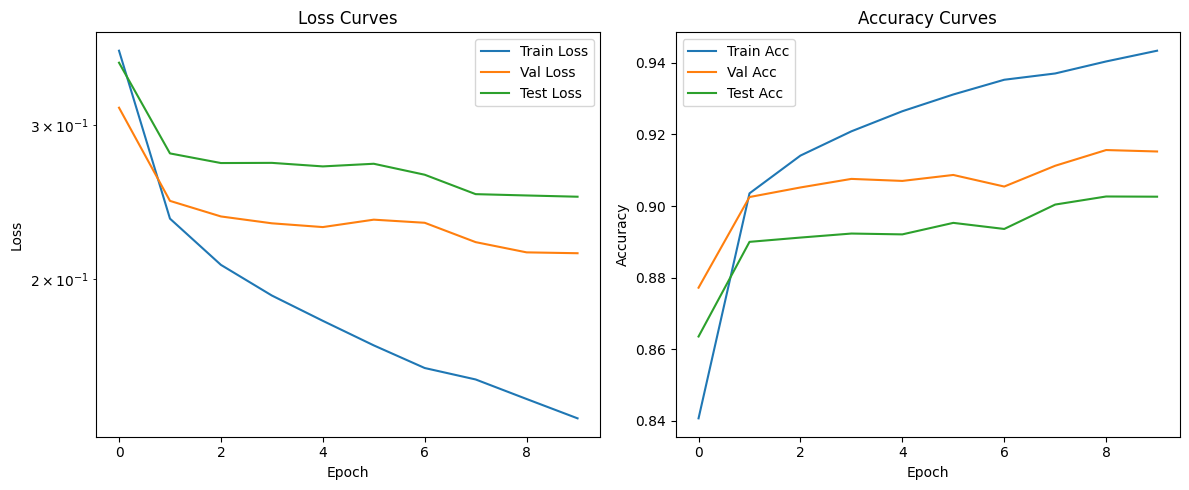

In [34]:
# Plot training curves for binary segmentation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(pet_seg_train_results["train_loss"], label="Train Loss")
plt.plot(pet_seg_train_results["val_loss"], label="Val Loss")
plt.plot(pet_seg_train_results["test_loss"], label="Test Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pet_seg_train_results["train_acc"], label="Train Acc")
plt.plot(pet_seg_train_results["val_acc"], label="Val Acc")
plt.plot(pet_seg_train_results["test_acc"], label="Test Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Run the cell below, and you will see your segmentation result. You can run the cell multiple times to see different result sets.


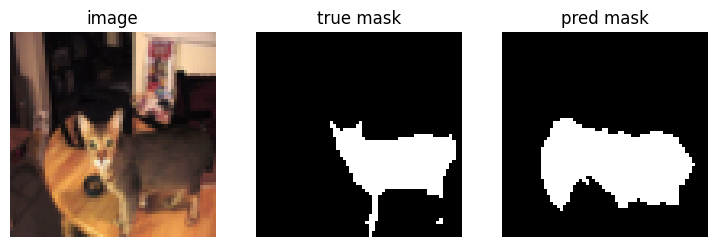

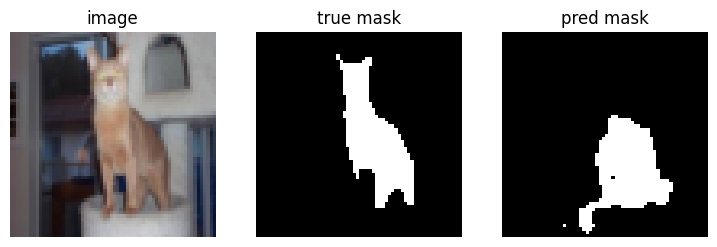

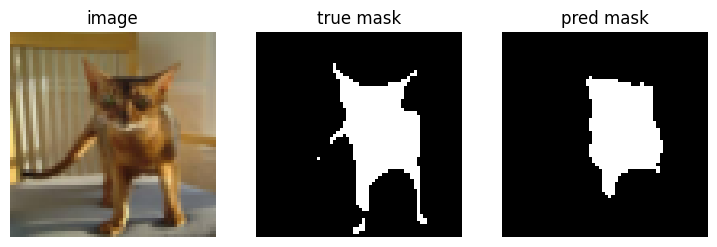

In [35]:
def visualize_predictions_binary(model, loader, n=3):
    """Show image + true mask + predicted mask for a few samples."""
    model.eval()
    xb, yb = next(iter(loader))
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)

    with torch.no_grad():
        logits = model(xb)
        # Accept (B,1,H,W) or (B,H,W)
        if logits.dim() == 4 and logits.size(1) == 1:
            probs = torch.sigmoid(logits[:, 0])
        else:
            probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    xb = xb.cpu()
    yb = yb.cpu()
    pred = pred.cpu()

    for i in range(min(n, xb.size(0))):
        plt.figure(figsize=(9, 3))
        plt.subplot(1, 3, 1)
        show_tensor_image(xb[i], title="image")
        plt.subplot(1, 3, 2)
        plt.imshow(yb[i].numpy(), cmap="gray")
        plt.axis("off")
        plt.title("true mask")
        plt.subplot(1, 3, 3)
        plt.imshow(pred[i].numpy(), cmap="gray")
        plt.axis("off")
        plt.title("pred mask")
        plt.show()


visualize_predictions_binary(model_deepcnn, test_pet_loader, n=3)


### 3.2 [209] U-Net for 3-Class Image Segmentation

This question is required for 209 students but optional for others.

Build a **U-Net** style architecture that predicts **3 classes per pixel** for the Oxford-IIIT Pet masks. Use an appropriate multi-class loss (e.g., cross-entropy), and report validation metrics. Store the trained model in a variable called `model_unet`.

As in the previous question, you should save the trained model and training history to disk to avoid retraining when notebook is re-run, reports final model's loss and accuracy on train, validation, and test, and plot loss and accuracy across for train and validation.


In [36]:
# Helper code for three-class segmentation (train/val/test)

pet_full_3c = PetSegDataset(pets_trainval, mode="three_class")
pet_test_3c = PetSegDataset(pets_test, mode="three_class")

VAL_SIZE = 800
pet_train_3c, pet_val_3c = split_train_val(
    pet_full_3c, val_size=VAL_SIZE, seed=SEED + 1
)

BATCH_PET_3C = 128 if DEVICE.type == "cuda" else 32
train_pet_3c_loader, val_pet_3c_loader, test_pet_3c_loader = make_loaders(
    pet_train_3c,
    pet_val_3c,
    pet_test_3c,
    BATCH_PET_3C,
    device=DEVICE,
    num_workers=NUM_WORKERS,
)

xb3, yb3 = next(iter(train_pet_3c_loader))
print("pet 3c batch:", xb3.shape, yb3.shape, "| mask unique:", torch.unique(yb3))


/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.

pet 3c batch: torch.Size([128, 3, 64, 64]) torch.Size([128, 64, 64]) | mask unique: tensor([0, 1, 2])


In [37]:
class ThreeClass_UNet(nn.Module):
    def __init__(self):
        super(ThreeClass_UNet, self).__init__()
        self.input_shape = (3, 64, 64)  # pet_full_bin[0][0].shape
        self.max_filters = 256

        # downwards architecture
        # dstep 1: 64x64 -> 64x64
        self.dconv1 = nn.Conv2d(3, self.max_filters >> 4, kernel_size=3, padding=1)
        self.dbn1 = nn.BatchNorm2d(self.max_filters >> 4)
        self.drelu1 = nn.ReLU()
        self.dconv2 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.dbn2 = nn.BatchNorm2d(self.max_filters >> 4)
        self.drelu2 = nn.ReLU()

        # dstep 2: 64x64 -> 32x32
        self.dpool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv4 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.dbn4 = nn.BatchNorm2d(self.max_filters >> 3)
        self.drelu4 = nn.ReLU()
        self.dconv5 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.dbn5 = nn.BatchNorm2d(self.max_filters >> 3)
        self.drelu5 = nn.ReLU()

        # dstep 3: 32x32 -> 16x16
        self.dpool6 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv7 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.dbn7 = nn.BatchNorm2d(self.max_filters >> 2)
        self.drelu7 = nn.ReLU()
        self.dconv8 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.dbn8 = nn.BatchNorm2d(self.max_filters >> 2)
        self.drelu8 = nn.ReLU()

        # dstep 4: 16x16 -> 8x8
        self.dpool9 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv10 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.dbn10 = nn.BatchNorm2d(self.max_filters >> 1)
        self.drelu10 = nn.ReLU()
        self.dconv11 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.dbn11 = nn.BatchNorm2d(self.max_filters >> 1)
        self.drelu11 = nn.ReLU()

        # dstep 5: 8x8 -> 4x4
        self.dpool12 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dconv13 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters, kernel_size=3, padding=1
        )
        self.dbn13 = nn.BatchNorm2d(self.max_filters)
        self.drelu13 = nn.ReLU()
        self.dconv14 = nn.Conv2d(
            self.max_filters, self.max_filters, kernel_size=3, padding=1
        )
        self.dbn14 = nn.BatchNorm2d(self.max_filters)
        self.drelu14 = nn.ReLU()

        # upsample architecture
        # step 1: 4x4 -> 8x8
        self.uupsample1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv1 = nn.Conv2d(
            self.max_filters, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn1 = nn.BatchNorm2d(self.max_filters >> 1)
        self.uconv2 = nn.Conv2d(
            self.max_filters, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn2 = nn.BatchNorm2d(self.max_filters >> 1)
        self.urelu2 = nn.ReLU()
        self.uconv3 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 1, kernel_size=3, padding=1
        )
        self.ubn3 = nn.BatchNorm2d(self.max_filters >> 1)
        self.urelu3 = nn.ReLU()

        # step 2: 8x8 -> 16x16
        self.uupsample4 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv4 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn4 = nn.BatchNorm2d(self.max_filters >> 2)
        self.uconv5 = nn.Conv2d(
            self.max_filters >> 1, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn5 = nn.BatchNorm2d(self.max_filters >> 2)
        self.urelu5 = nn.ReLU()
        self.uconv6 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 2, kernel_size=3, padding=1
        )
        self.ubn6 = nn.BatchNorm2d(self.max_filters >> 2)
        self.urelu6 = nn.ReLU()

        # step 3: 16x16 -> 32x32
        self.uupsample7 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv7 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn7 = nn.BatchNorm2d(self.max_filters >> 3)
        self.uconv8 = nn.Conv2d(
            self.max_filters >> 2, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn8 = nn.BatchNorm2d(self.max_filters >> 3)
        self.urelu8 = nn.ReLU()
        self.uconv9 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 3, kernel_size=3, padding=1
        )
        self.ubn9 = nn.BatchNorm2d(self.max_filters >> 3)
        self.urelu9 = nn.ReLU()

        # step 4: 32x32 -> 64x64
        self.uupsample10 = nn.Upsample(scale_factor=2, mode="nearest")
        self.uconv10 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn10 = nn.BatchNorm2d(self.max_filters >> 4)
        self.uconv11 = nn.Conv2d(
            self.max_filters >> 3, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn11 = nn.BatchNorm2d(self.max_filters >> 4)
        self.urelu11 = nn.ReLU()
        self.uconv12 = nn.Conv2d(
            self.max_filters >> 4, self.max_filters >> 4, kernel_size=3, padding=1
        )
        self.ubn12 = nn.BatchNorm2d(self.max_filters >> 4)
        self.urelu12 = nn.ReLU()

        # final conv to get 3 output channels for 3-class segmentation
        self.final_conv = nn.Conv2d(self.max_filters >> 4, 3, kernel_size=1)

    def forward(self, x):
        # downsample
        x = self.drelu1(self.dbn1(self.dconv1(x)))
        x = self.drelu2(self.dbn2(self.dconv2(x)))
        skip1 = x.clone()  # 64x64

        x = self.dpool3(x)
        x = self.drelu4(self.dbn4(self.dconv4(x)))
        x = self.drelu5(self.dbn5(self.dconv5(x)))
        skip2 = x.clone()  # 32x32

        x = self.dpool6(x)
        x = self.drelu7(self.dbn7(self.dconv7(x)))
        x = self.drelu8(self.dbn8(self.dconv8(x)))
        skip3 = x.clone()  # 16x16

        x = self.dpool9(x)
        x = self.drelu10(self.dbn10(self.dconv10(x)))
        x = self.drelu11(self.dbn11(self.dconv11(x)))
        skip4 = x.clone()  # 8x8

        x = self.dpool12(x)
        x = self.drelu13(self.dbn13(self.dconv13(x)))
        x = self.drelu14(self.dbn14(self.dconv14(x)))  # 4x4

        # upsample
        x = self.ubn1(self.uconv1(self.uupsample1(x)))
        x = self.urelu2(self.ubn2(self.uconv2(torch.cat([x, skip4], dim=1))))
        x = self.urelu3(self.ubn3(self.uconv3(x)))  # 8x8

        x = self.ubn4(self.uconv4(self.uupsample4(x)))
        x = self.urelu5(self.ubn5(self.uconv5(torch.cat([x, skip3], dim=1))))
        x = self.urelu6(self.ubn6(self.uconv6(x)))  # 16x16

        x = self.ubn7(self.uconv7(self.uupsample7(x)))
        x = self.urelu8(self.ubn8(self.uconv8(torch.cat([x, skip2], dim=1))))
        x = self.urelu9(self.ubn9(self.uconv9(x)))  # 32x32

        x = self.ubn10(self.uconv10(self.uupsample10(x)))
        x = self.urelu11(self.ubn11(self.uconv11(torch.cat([x, skip1], dim=1))))
        x = self.urelu12(self.ubn12(self.uconv12(x)))  # 64x64

        x = self.final_conv(x)  # 64x64, 3 channels
        return x  # (B, 3, H, W) -> (B, H, W)


# model object
model_unet = ThreeClass_UNet()


In [38]:
UNET_CHECKPOINT_PATH = Path("/mnt/ssd/Ubuntu-24.04/ssd-cs1090b/hw2/unet/")
UNET_CHECKPOINT_PATH.mkdir(exist_ok=True, parents=True)


def train_unet_model(
    model, train_loader, val_loader, test_loader, device, num_epochs=10
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        for xb, yb in tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Train", leave=False
        ):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb.long())
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.numel()

        train_loss /= len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for xb, yb in tqdm(
                val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Val", leave=False
            ):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb.long())
                val_loss += loss.item() * xb.size(0)

                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.numel()

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Test
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for xb, yb in tqdm(
                test_loader, desc=f"Epoch {epoch + 1}/{num_epochs} - Test", leave=False
            ):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb.long())
                test_loss += loss.item() * xb.size(0)

                preds = torch.argmax(logits, dim=1)
                correct_test += (preds == yb).sum().item()
                total_test += yb.numel()

        test_loss /= len(test_loader.dataset)
        test_acc = correct_test / total_test
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

        # Save model checkpoint
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "performance": {
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
            },
        }
        torch.save(checkpoint, UNET_CHECKPOINT_PATH / f"checkpoint_epoch_{epoch}.pt")

    return history


In [ ]:
# Define and train a U-Net for 3-class segmentation
# Build, train, and evaluate final binary segmentation model
UNET_METRICS_PATH = UNET_CHECKPOINT_PATH / "metrics_unet.pt"

unet_num_epochs = 10
unet_train_results = None

if (UNET_CHECKPOINT_PATH / f"checkpoint_epoch_{unet_num_epochs - 1}.pt").exists():
    print("already trained, skipping training...")
    unet_train_results = torch.load(UNET_METRICS_PATH)
else:
    unet_train_results = train_unet_model(
        model_unet,
        train_pet_3c_loader,
        val_pet_3c_loader,
        test_pet_3c_loader,
        DEVICE,
        num_epochs=unet_num_epochs,
    )
    torch.save(unet_train_results, UNET_METRICS_PATH)

# load best checkpoint
unet_best_epoch = np.argmax(unet_train_results["val_acc"])
unet_best_checkpoint = torch.load(
    UNET_CHECKPOINT_PATH / f"checkpoint_epoch_{unet_best_epoch}.pt"
)
model_unet.load_state_dict(unet_best_checkpoint["model_state_dict"])


Epoch 1/10 - Train:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/7 [00:00<?, ?it/s]            /home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")
/home/andrew/harvard/cs1090b/hw/hw2/.venv/lib/python3.12/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Arg

Epoch 1/10 | Train Loss: 0.8039, Train Acc: 0.6802 | Val Loss: 0.7644, Val Acc: 0.7147 | Test Loss: 0.7775, Test Acc: 0.7052


Epoch 2/10 | Train Loss: 0.6448, Train Acc: 0.7631 | Val Loss: 0.6682, Val Acc: 0.7553 | Test Loss: 0.6822, Test Acc: 0.7465


Epoch 3/10 | Train Loss: 0.5653, Train Acc: 0.7907 | Val Loss: 0.5393, Val Acc: 0.7971 | Test Loss: 0.5467, Test Acc: 0.7931


...

Epoch 7/10 | Train Loss: 0.4071, Train Acc: 0.8453 | Val Loss: 0.4581, Val Acc: 0.8227 | Test Loss: 0.4539, Test Acc: 0.8247


Epoch 8/10 | Train Loss: 0.3936, Train Acc: 0.8494 | Val Loss: 0.5134, Val Acc: 0.8007 | Test Loss: 0.5234, Test Acc: 0.7977


Epoch 9/10 | Train Loss: 0.3660, Train Acc: 0.8599 | Val Loss: 0.4483, Val Acc: 0.8279 | Test Loss: 0.4449, Test Acc: 0.8306


Epoch 10/10 | Train Loss: 0.3455, Train Acc: 0.8676 | Val Loss: 0.4357, Val Acc: 0.8328 | Test Loss: 0.4377, Test Acc: 0.8329


<All keys matched successfully>

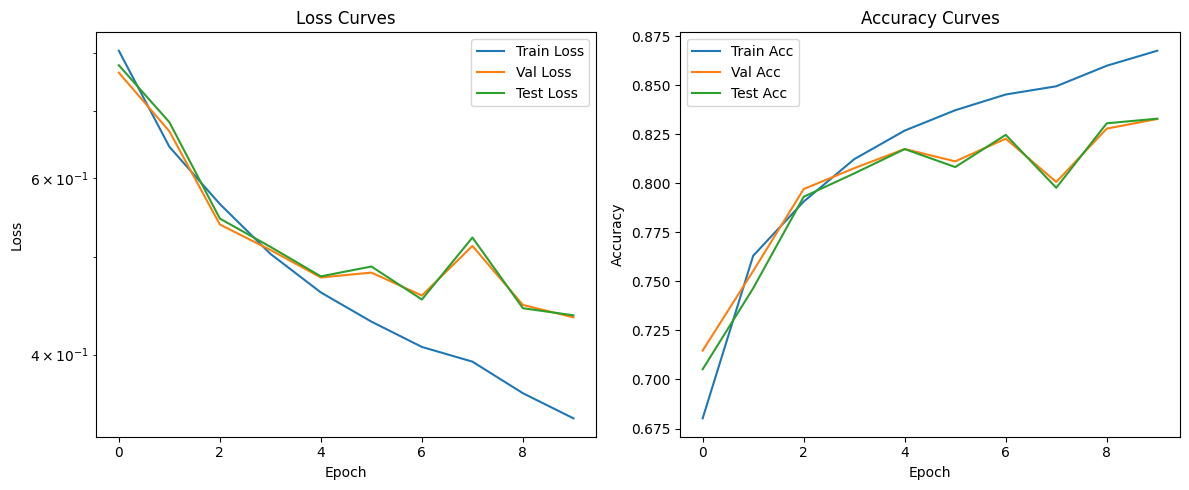

In [40]:
# Plot training curves for U-Net
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(unet_train_results["train_loss"], label="Train Loss")
plt.plot(unet_train_results["val_loss"], label="Val Loss")
plt.plot(unet_train_results["test_loss"], label="Test Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(unet_train_results["train_acc"], label="Train Acc")
plt.plot(unet_train_results["val_acc"], label="Val Acc")
plt.plot(unet_train_results["test_acc"], label="Test Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


Run the cell below to visualize segmentation predictions from your 3-class model. Re-run to view different batches.


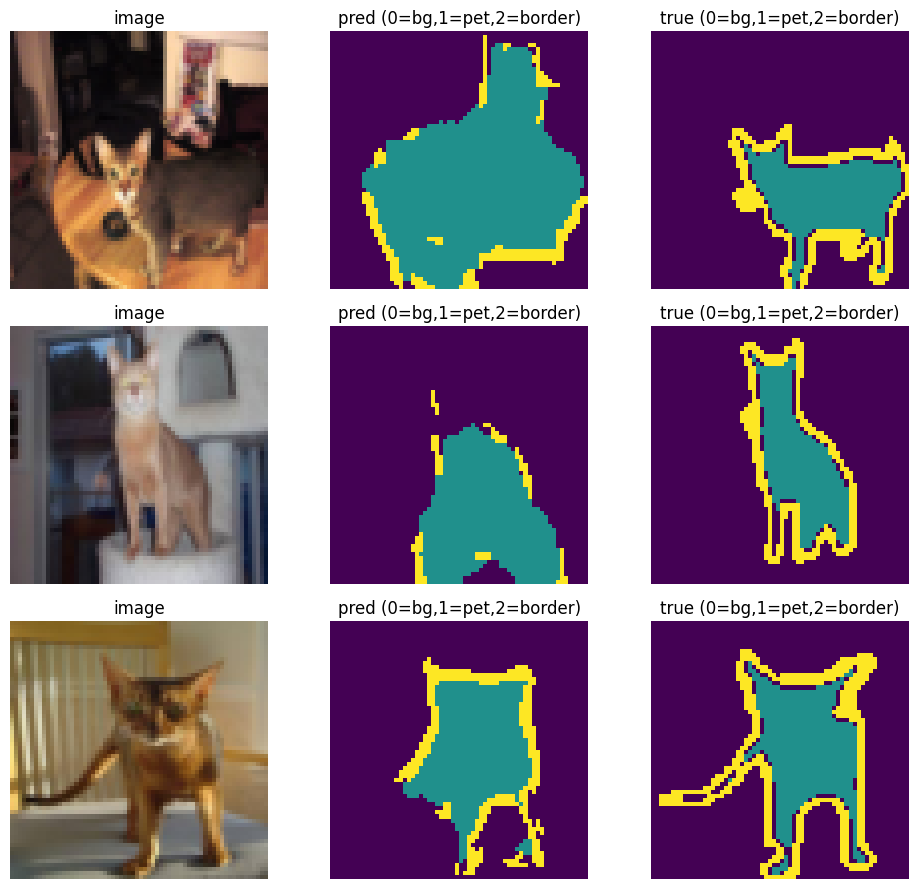

In [41]:
# Run to visualize U-Net predictions
def visualize_predictions_3class(model: nn.Module, loader: DataLoader, n: int = 3):
    model.eval()
    xb, yb = next(iter(loader))
    xb = xb[:n].to(DEVICE)
    yb = yb[:n]

    with torch.no_grad():
        logits = model(xb).cpu()
        pred = logits.argmax(dim=1)

    plt.figure(figsize=(10, 3 * n))
    for i in range(n):
        img = denorm_01(xb[i].cpu()).permute(1, 2, 0).numpy()
        true = yb[i].numpy()
        pr = pred[i].numpy()

        plt.subplot(n, 3, 3 * i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("image")

        plt.subplot(n, 3, 3 * i + 2)
        plt.imshow(pr, vmin=0, vmax=2)
        plt.axis("off")
        plt.title("pred (0=bg,1=pet,2=border)")

        plt.subplot(n, 3, 3 * i + 3)
        plt.imshow(true, vmin=0, vmax=2)
        plt.axis("off")
        plt.title("true (0=bg,1=pet,2=border)")
    plt.tight_layout()
    plt.show()


visualize_predictions_3class(model_unet, test_pet_3c_loader, n=3)


## Wrap-up

- In a few sentences, please describe the aspect(s) of the assignment you found most challenging. This could be conceptual and/or related to coding and implementation.

- How many hours did you spend working on this assignment? Store this as an int or float in `hours_spent_on_hw`. If you worked on the project in a group, report the _average_ time spent per person.


Honestly, it was figuring out how to get WSL to use the natively mounted external SSD instead of the Windows connection.


In [ ]:
hours_spent_on_hw = 8


In [ ]:
assert float(hours_spent_on_hw), (
    "Please select a time in hours (int or float) to specify how long you spent on this assignment."
)


In [ ]:
time_end = time.time()
print(f"It took {(time_end - time_start) / 60:.2f} minutes for this notebook to run")


**This concludes HW2. Thank you!**
